<a href="https://colab.research.google.com/github/EdvanylsonAssuncao/curso_IA_generativa/blob/main/reconhecimento_facial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# RECONHECIMENTO FACIAL E COMPARAÇÃO VETORIAL
!pip install face_recognition opencv-python
import cv2
import face_recognition
from google.colab.patches import cv2_imshow

[SISTEMA] Carregando imagem e gerando vetor de 128 números ...

Distância calculada entre os rostos: 0.2765

--- Resultado da Análise do Biometria Facial ---


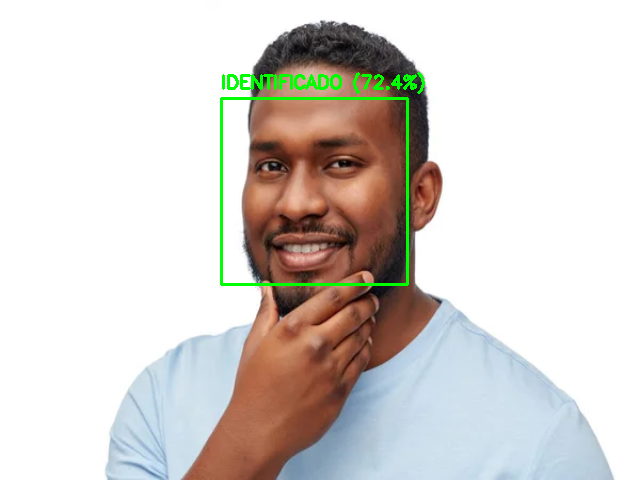

In [13]:
# 1. Carregar a refeência (o cadastro no banco de dados)
print("[SISTEMA] Carregando imagem e gerando vetor de 128 números ...")

foto_referencia = face_recognition.load_image_file("referencia.jpg")
encoding_referencia = face_recognition.face_encodings(foto_referencia)[0]

# 2. Carregar a foto de teste para comparação
imagem_analise = cv2.imread("teste_sucesso.jpg")
imagem_analise = cv2.resize(imagem_analise, (640, 480))

# 3. Conversão obrigatótia: face_recognition lê em RGB, mas o OpenCV lê em BGR
imagem_analise_rgb = cv2.cvtColor(imagem_analise, cv2.COLOR_BGR2RGB)

# 4. Localizar rosto na foto e extrair seus encodings
locais_dos_rostos = face_recognition.face_locations(imagem_analise_rgb)
encodings_dos_rostos = face_recognition.face_encodings(imagem_analise_rgb, locais_dos_rostos)

# 5. "Varre" o rosto encontrado na foto
for (topo, direita, fundo, esquerda), encodings_rosto_atual in zip(locais_dos_rostos, encodings_dos_rostos):

    # Calcular a distância matemática entre as duas assinaturas
    distancia = face_recognition.face_distance([encoding_referencia], encodings_rosto_atual)[0]
    print(f"\nDistância calculada entre os rostos: {distancia:.4f}")

    # Lógica de Threshold
    if distancia < 0.6:
        label_texto = f"IDENTIFICADO ({100 - (distancia*100):.1f}%)"
        cor_borda = (0, 255, 0) # Verde para sucesso
    else:
        label_texto = "DESCONHECIDO"
        cor_borda = (0, 0, 255) # Vermelho para intruso

    # 6. Utilização do OpenCV para desenhar feedback na tela
    cv2.rectangle(imagem_analise, (esquerda, topo), (direita, fundo), cor_borda, 2)
    cv2.putText(imagem_analise, label_texto, (esquerda, topo -10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, cor_borda, 2)

    # 7. Exibir o diagnóstico visual na tela
    print("\n--- Resultado da Análise do Biometria Facial ---")
    cv2_imshow(imagem_analise)